In [2]:
import numpy as np
import pandas as pd
import pprint
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [3]:
!pip install openai
import openai

# Get and assign key
from google.colab import userdata
key = userdata.get('OpenAI')
openai.api_key = key
client = openai.OpenAI(api_key=key)

In [6]:
# Setup
present_date = pd.to_datetime('2025-05-01')

# Load Leads

In [7]:
date_columns = ['open_date', 'close_date', 'renewal_date', 'snapshot_date']
# Read
df_snapshots = pd.read_csv(dir + '/lead_snapshots.csv', parse_dates=date_columns)
df_snapshots

,id,company_name,industry,mock_source,status,converted,open_date,close_date,company_summary,favorability,...,competitor_solution,renewal_date,deal_value,snapshot_date,snapshot_seq,lead_stage,downloads,website_visits,interactions,decision_maker_level
0,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,Unknown,NaT,Unknown,2024-08-27,1,Prospecting,1,2,2,Manager
1,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,Unknown,NaT,Unknown,2024-09-10,2,Prospecting,1,1,2,Director
2,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,Unknown,NaT,Unknown,2024-09-24,3,Prospecting,1,2,2,Director
3,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,Unknown,NaT,Unknown,2024-10-08,4,Prospecting,0,2,2,Director
4,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,Unknown,NaT,Unknown,2024-10-22,5,Qualified,1,2,6,Director
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5332,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,Competitor Solution,2025-08-16,72000,2024-08-08,5,Proposal,3,6,8,Exec/CIO/CISO
5333,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,Competitor Solution,2025-08-16,72000,2024-08-22,6,Proposal,3,6,8,Exec/CIO/CISO
5334,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,Competitor Solution,2025-08-16,72000,2024-09-05,7,Negotiation,3,6,10,Exec/CIO/CISO
5335,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,Competitor Solution,2025-08-16,72000,2024-09-19,8,Negotiation,3,6,10,Exec/CIO/CISO


# Data Exploration

In [8]:
# display(df_snapshots.info())

# Group snapshots by lead to get summary
df_leads = df_snapshots.groupby('id').agg({
    'company_name': 'first',
    'industry': 'first',
    'mock_source': 'first',
    'status': 'first',
    'converted': 'first',
    'open_date': 'first',
    'close_date': 'first',
    'company_summary': 'first',
    'favorability': 'first',
    'cyber_investment': 'last',
    'competitor_solution': 'last',
    'renewal_date': 'last',
    'deal_value': 'last',
    'snapshot_date': 'last',    # Last lead contact
    'snapshot_seq': 'last',
    'decision_maker_level': 'last',
    'lead_stage': 'last',
    'downloads': 'sum',
    'website_visits': 'sum',
    'interactions': 'sum'
    }).reset_index()

# Rename
df_leads.rename(columns={'snapshot_date': 'last_snapshot_date'}, inplace=True)
# Display
df_leads

,id,company_name,industry,mock_source,status,converted,open_date,close_date,company_summary,favorability,...,competitor_solution,renewal_date,deal_value,last_snapshot_date,snapshot_seq,decision_maker_level,lead_stage,downloads,website_visits,interactions
0,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,Unknown,NaT,53000,2025-01-15,12,Director,Lost,14,29,54
1,ACC0002,Las Vegas Sands,Gaming & Hospitality,topglobal,Open,NaN,2024-11-30,NaT,Las Vegas Sands is a prominent player in the G...,14,...,Unknown,NaT,54000,2025-05-01,12,Director,Prospecting,0,3,0
2,ACC0003,State Bank of India,Banking,topglobal,Closed,1.0,2024-10-22,2025-03-10,State Bank of India is a prominent player in t...,98,...,Unknown,NaT,293000,2025-03-10,11,VP,Converted,26,53,77
3,ACC0004,Simpson Strong-Tie,Manufacturing (Construction Connectors),customer,Closed,1.0,2023-12-31,2024-06-11,Simpson Strong-Tie is a prominent player in th...,89,...,No Solution,NaT,87000,2024-06-11,13,VP,Converted,26,59,90
4,ACC0005,Beijing Entreprises,Conglomerate,topglobal,Closed,0.0,2024-06-19,2024-12-06,Beijing Entreprises is a prominent conglomerat...,23,...,Competitor Solution,2025-10-10,56000,2024-12-06,14,Director,Lost,6,5,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,ACC0402,Ocean Bank,Banking (Commercial Bank),similar,Closed,0.0,2024-08-05,2024-12-18,Ocean Bank is a distinguished commercial bank ...,88,...,No Solution,NaT,68000,2024-12-18,11,VP,Lost,22,49,72
402,ACC0403,Navy Federal Credit Union,Financial Services (Credit Union),customer,Closed,1.0,2024-02-13,2024-06-28,Navy Federal Credit Union is a trusted financi...,70,...,Unknown,NaT,75000,2024-06-28,11,Exec/CIO/CISO,Converted,17,40,61
403,ACC0404,Grifols,Biotechnology & Pharmaceuticals,topglobal,Open,NaN,2025-01-07,NaT,Grifols is a distinguished player in the biote...,30,...,Competitor Solution,2027-10-21,46000,2025-05-01,10,Director,Qualified,5,8,27
404,ACC0405,Galaxy Entertainment,Gaming & Hospitality,topglobal,Closed,0.0,2024-07-25,2024-12-28,Galaxy Entertainment is a renowned player in t...,77,...,No Solution,NaT,55000,2024-12-28,13,VP,Lost,24,56,85


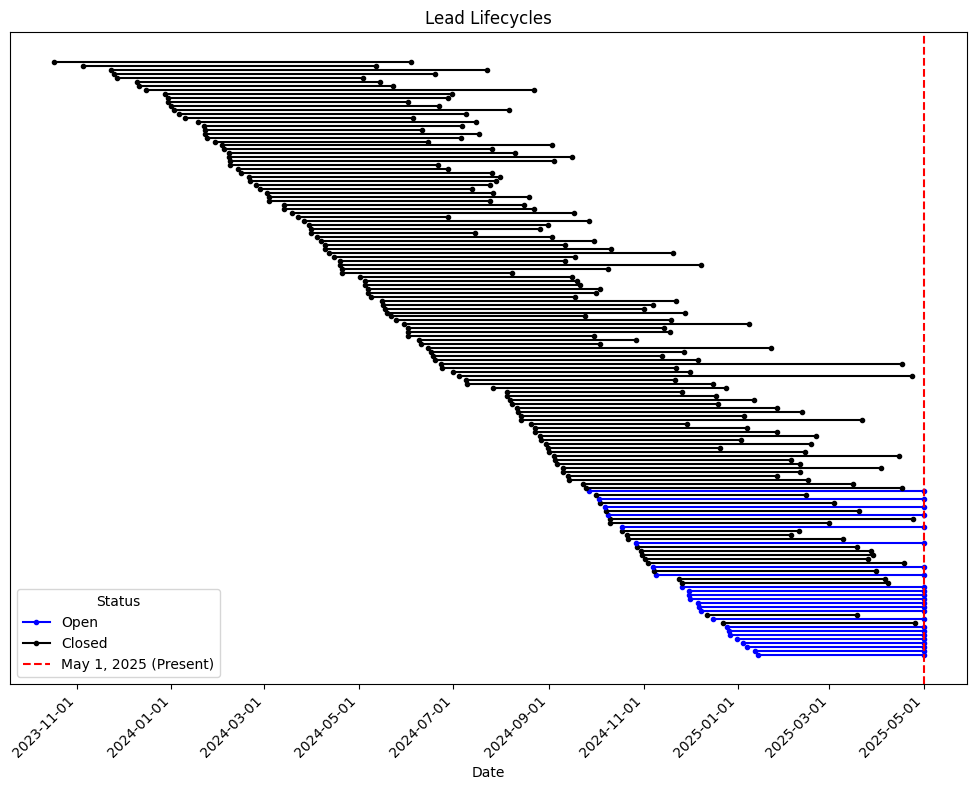

In [40]:
# Set temporary close date for visualization
df_leads_temp = df_leads.copy()
df_leads_temp = df_leads_temp.sample(n=150, random_state=54) # Sample for readability
df_leads_temp['close_date'] = df_leads_temp['close_date'].fillna(present_date)    # Temporary close date for now
df_leads_temp = df_leads_temp.sort_values(by='open_date', ascending=False).reset_index(drop=True)   # Sort by Open Date

colors = {'Open': 'blue', 'Closed': 'black'}

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the open and close dates as lines
for index, row in df_leads_temp.iterrows():
    open_date = row['open_date']
    close_date = row['close_date']
    status = row['status']
    color = colors.get(status, 'orange')  # Default to blue if status not in colors

    # Plot a line segment from Open Date to Close Date
    ax.plot([open_date, close_date], [index, index], marker='o', markersize=3, linestyle='-', color=color, label=status)

# Add a vertical line at 2025-05-01
vertical_date = pd.to_datetime('2025-05-01')
ax.axvline(vertical_date, color='red', linestyle='--', label='May 1, 2025 (Present)')

# Set x-axis label and format
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')

# Remove y-axis ticks and labels
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel(None)  # Optional: Remove the y-axis label entirely

# Set title
plt.title('Lead Lifecycles')

# Add legend (only show one label per status)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Status')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Show the plot
plt.show()

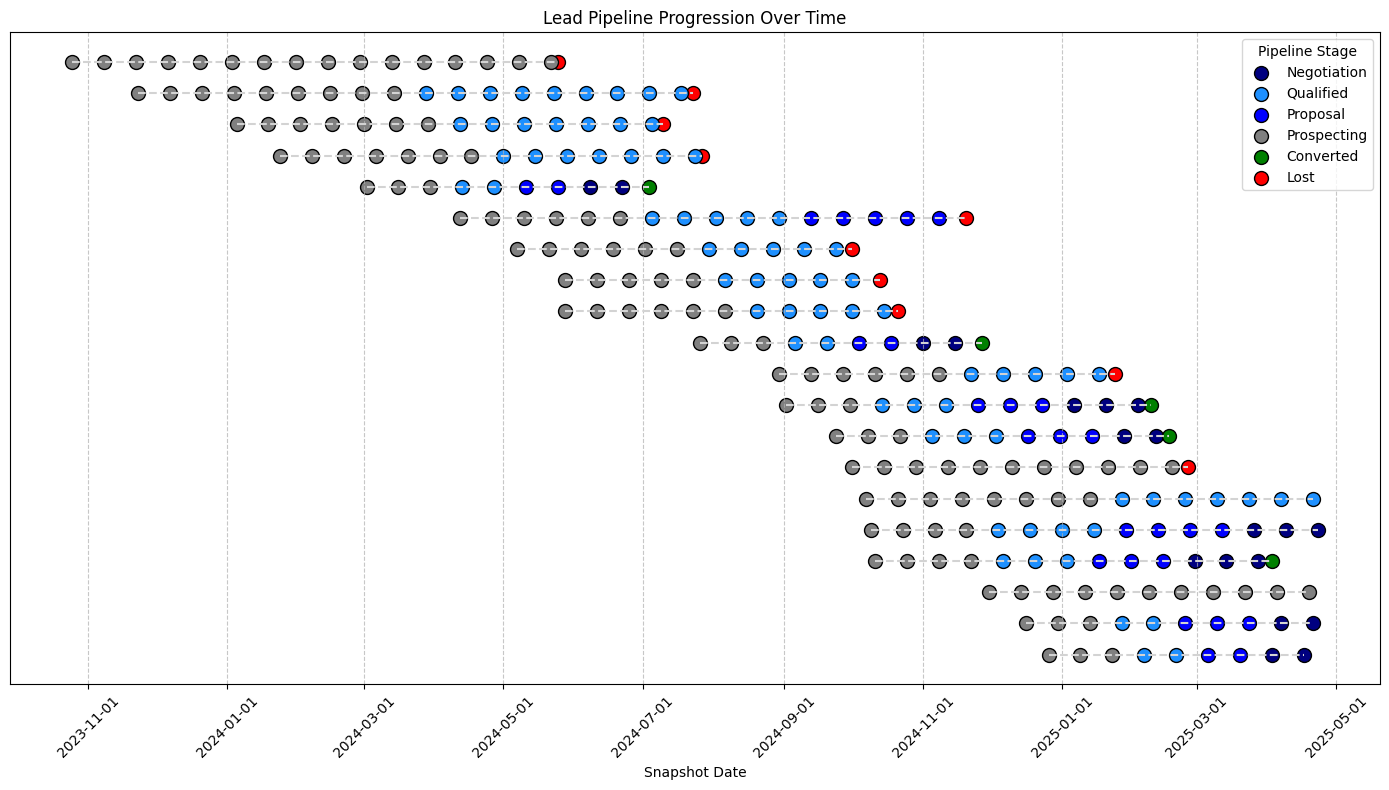

In [10]:
# Sample random unique leads
sampled_leads = df_snapshots['id'].drop_duplicates().sample(n=20, random_state=649)
# Filter the snapshots to just these leads
df_snapshots_temp = df_snapshots[df_snapshots['id'].isin(sampled_leads)]
# Sort by date
df_snapshots_temp = df_snapshots_temp.sort_values(by='open_date', ascending=False).reset_index(drop=True)

# Example stage -> color mapping
stage_colors = {
    'Prospecting': 'gray',
    'Qualified': 'dodgerblue',
    'Proposal': 'blue',
    'Negotiation': 'navy',
    'Converted': 'green',
    'Lost': 'red',
    }

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Ensure snapshot_date is datetime
df_snapshots_temp['snapshot_date'] = pd.to_datetime(df_snapshots_temp['snapshot_date'])

# Get unique leads
leads = df_snapshots_temp['id'].unique()

# Map each lead to a y-position
lead_y_positions = {lead: i for i, lead in enumerate(leads)}

# Plot each snapshot
for _, row in df_snapshots_temp.iterrows():
    lead_id = row['id']
    x = row['snapshot_date']
    y = lead_y_positions[lead_id]
    stage = row['lead_stage']
    color = stage_colors.get(stage, 'black')  # fallback to black if missing

    ax.scatter(x, y, color=color, label=stage, s=100, edgecolor='k')

# Draw a horizontal line for each lead
for lead_id, y in lead_y_positions.items():
    lead_snapshots = df_snapshots_temp[df_snapshots_temp['id'] == lead_id]
    min_date = lead_snapshots['snapshot_date'].min()
    max_date = lead_snapshots['snapshot_date'].max()
    ax.plot([min_date, max_date], [y, y], color='lightgray', linestyle='--')

# Formatting
ax.set_xlabel('Snapshot Date')
ax.set_title('Lead Pipeline Progression Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Remove y-axis ticks and labels
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel(None)  # Optional: Remove the y-axis label entirely

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Pipeline Stage')

plt.tight_layout()
plt.show()

In [11]:
import plotly.graph_objects as go
from collections import Counter

# Step 1: Sort snapshots by lead and sequence
df_snapshots_sorted = df_snapshots.sort_values(by=['id', 'snapshot_seq'])

# Step 2: For each lead, get ordered list of distinct stages
transitions = []
for lead_id, group in df_snapshots_sorted.groupby('id'):
    stages = group['lead_stage'].tolist()
    # Remove consecutive duplicates
    stages = [s for i, s in enumerate(stages) if i == 0 or s != stages[i-1]]
    # Create stage-to-stage transitions
    transitions += list(zip(stages[:-1], stages[1:]))

# Step 3: Count transitions
transition_counts = Counter(transitions)

# Step 4: Convert to DataFrame for Sankey
df_sankey = pd.DataFrame(transition_counts.items(), columns=['transition', 'count'])
df_sankey[['source', 'target']] = pd.DataFrame(df_sankey['transition'].tolist(), index=df_sankey.index)
df_sankey = df_sankey[['source', 'target', 'count']]

## ---- Plot ----
# Get all unique stages for indexing
all_nodes = list(set(df_sankey['source']).union(set(df_sankey['target'])))
node_indices = {stage: i for i, stage in enumerate(all_nodes)}

# Map stages to numeric indices
df_sankey['source_idx'] = df_sankey['source'].map(node_indices)
df_sankey['target_idx'] = df_sankey['target'].map(node_indices)

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=df_sankey['source_idx'],
        target=df_sankey['target_idx'],
        value=df_sankey['count']
    )
)])

fig.update_layout(title_text="Lead Stage Transitions", font_size=14)
fig.show()

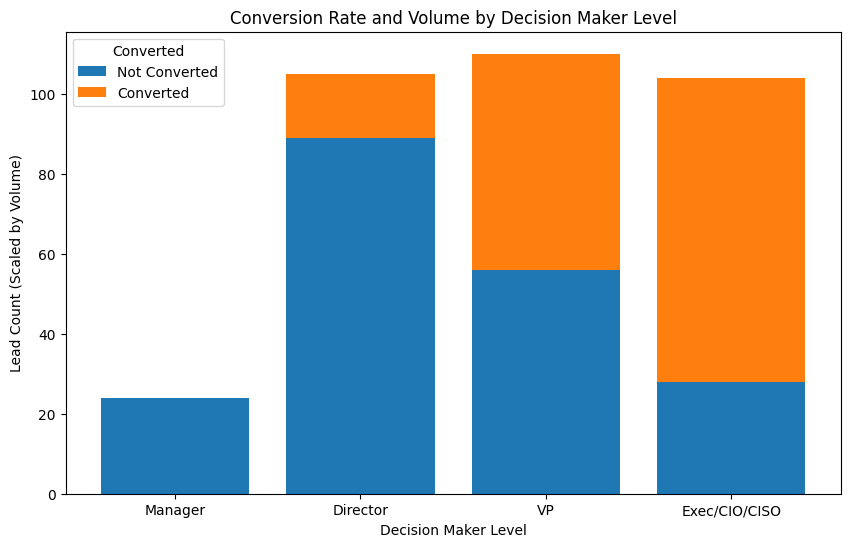

In [14]:
# Filter for CLOSED leads
closed_leads = df_leads[df_leads['status'] == 'Closed']

# Define order
order = ['Manager', 'Director', 'VP', 'Exec/CIO/CISO']

# Absolute counts
counts = closed_leads.groupby(['decision_maker_level', 'converted']).size().unstack(fill_value=0).loc[order]

# Total count per decision maker level
totals = counts.sum(axis=1)

# Proportions
proportions = counts.div(totals, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(order))
x = np.arange(len(order))

for i, converted_label in enumerate(proportions.columns):
    height = proportions[converted_label] * totals  # Scale by total volume
    ax.bar(x, height, bottom=bottom, label='Converted' if converted_label else 'Not Converted')
    bottom += height

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_xlabel('Decision Maker Level')
ax.set_ylabel('Lead Count (Scaled by Volume)')
ax.set_title('Conversion Rate and Volume by Decision Maker Level')
ax.legend(title='Converted')
plt.show()

# Lead Summarization

Generate a summary of the current state of the lead. Use a key-value semi-structured summary for easier comparison.

For a given snapshot, input previous snapshots. Agent should provide:
- Age of lead
- Deal value
- Current stage. Signs of stagnation
- Engagement and trends.
- Decision-maker level engagement
- Cyber investment
- Competitor solutions and time until renewal
- Other key notes

Insert company summary to beginning.

## Prompt Generation

In [9]:
def format_snapshot(row):
    return f"""- Date: {row['snapshot_date'].date()}
    Lead Stage: {row['lead_stage']}
    Lead Deal Value: {row['deal_value']}
    Downloads Engagement: {row['downloads']}
    Website Visits Engagement: {row['website_visits']}
    Interactions Engagement: {row['interactions']}
    Most Senior Contact: {row['decision_maker_level']}
    """

def write_snapshot_prompts(df_snapshots):
    # Ensure correct order for historical tracking
    df_snapshots = df_snapshots.sort_values(by=['id', 'snapshot_date'])

    prompts = []

    for id, group in df_snapshots.groupby('id'):

        history = []
        for i, row in group.iterrows():
            history.append(row)  # Add current snapshot

            # Generate history string from all snapshots so far (including current)
            history_str = "\n".join(format_snapshot(r) for r in history)

            # Send to GPT as part of the prompt
            prompt = f"""Summarize the state and history of the sales lead.
Do not make recommendations. Use only the information provided. If any information is unknown, write 'Not available.'

Company: {row['company_name']}
Industry: {row['industry']}
Cyber Investment Level: {row['cyber_investment']}
Competitor Solutions: {row['competitor_solution']}
Competitor Renewal Date: {row['renewal_date']}

Lead Snapshot History:
{history_str}

The lead open date is {row['open_date'].date()}. The current date is {row['snapshot_date'].date()}.

Response Output Format:

Lead Stage:
  - Report the lead age in weeks since the lead opened.
  - Report the current lead stage and the number of weeks the lead has been in this stage.
  - Describe whether the lead stage advanced, remained in the same stage, or stagnated over time. Stagnation occurs if the stage does not advance for 6 weeks or more.

Lead Revenue: [Report the most recent known lead deal value.]
  - Report the most recent known deal value.

Investment:
  - State the cyber investment level.
  - State if there is a competitor solution, and state how many months remain until the competitor's renewal date.

Engagement:
  - Summarize trends for each engagement type (downloads, website visits, interactions).
  - Indicate whether each metric increased, decreased, remained flat, or fluctuated.
  - Mention any spikes or periods of low activity.

Senior Contact:
  - State the current most senior contact's title.
  - Note if there has been a recent progression in the seniority of the most senior contact. State how many weeks ago this progression occurred and in what lead stage.

Do not use specific dates in your output. Only use relative time references (e.g., "X weeks ago,").
Ensure the output is in full, natural sentences for each label. Do not use bullet points, and ensure that the information is formatted in readable paragraphs under each label as described.
"""
            # Append to prompts list
            prompts.append(prompt)

    return prompts

In [12]:
# df_snapshots = df_snapshots.head(100) # Sample for readability #TODO remove later

# Sort
df_snapshots = df_snapshots.sort_values(by=['id', 'snapshot_date'])

# Create custom summary prompts for each snapshot
prompts = write_snapshot_prompts(df_snapshots)
df_snapshots['prompt'] = prompts

In [48]:
print(prompts[5])

Summarize the state and history of the sales lead. 
Do not make recommendations. Use only the information provided. If any information is unknown, write 'Not available.'

Company: BCI-Banco Credito
Industry: Banking
Cyber Investment Level: Very High
Competitor Solutions: Unknown
Competitor Renewal Date: NaT

Lead Snapshot History:
- Date: 2024-08-27
    Lead Stage: Prospecting
    Lead Deal Value: Unknown
    Downloads Engagement: 1
    Website Visits Engagement: 2
    Interactions Engagement: 2
    Most Senior Contact: Manager
    
- Date: 2024-09-10
    Lead Stage: Prospecting
    Lead Deal Value: Unknown
    Downloads Engagement: 1
    Website Visits Engagement: 1
    Interactions Engagement: 2
    Most Senior Contact: Director
    
- Date: 2024-09-24
    Lead Stage: Prospecting
    Lead Deal Value: Unknown
    Downloads Engagement: 1
    Website Visits Engagement: 2
    Interactions Engagement: 2
    Most Senior Contact: Director
    
- Date: 2024-10-08
    Lead Stage: Prospecting


## Generate Snapshot Summaries

In [15]:
def generate_snapshot_summary(row, temperature=0.3, max_tokens=500):

    prompt = row['prompt']

    # Use the new API method for generating completions
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=temperature,
        max_tokens=max_tokens
    )
    response =  response.choices[0].message.content.strip()

    # Generate full lead snapshot summary.
    snapshot_summary = f"""Company Summary: {row['company_summary']}

{response}
    """

    return snapshot_summary

Batch process to retain data and save cost in case of failure

In [17]:
# Create new column with snapshot summaries
batch_size = 100

# Iterate through by batch size generating snap summaries. Then save as csv
for i in range(0, len(df_snapshots), batch_size):
    print(f"Processing rows {i} to {i + batch_size - 1}")
    # Get batch from dataframe
    batch = df_snapshots.iloc[i:i+batch_size].copy()  # Copy
    # Apply to batch
    batch['snapshot_summary'] = batch.apply(generate_snapshot_summary, axis=1)
    # Add results to original dataframe
    df_snapshots.loc[i:i+batch_size-1, 'snapshot_summary'] = batch['snapshot_summary']
    # Save current version
    df_snapshots.to_csv(dir + '/snapshots_summarized.csv', index=False)

Processing rows 0 to 99
Processing rows 100 to 199
Processing rows 200 to 299
Processing rows 300 to 399
Processing rows 400 to 499
Processing rows 500 to 599
Processing rows 600 to 699
Processing rows 700 to 799
Processing rows 800 to 899
Processing rows 900 to 999
Processing rows 1000 to 1099
Processing rows 1100 to 1199
Processing rows 1200 to 1299
Processing rows 1300 to 1399
Processing rows 1400 to 1499
Processing rows 1500 to 1599
Processing rows 1600 to 1699
Processing rows 1700 to 1799
Processing rows 1800 to 1899
Processing rows 1900 to 1999
Processing rows 2000 to 2099
Processing rows 2100 to 2199
Processing rows 2200 to 2299
Processing rows 2300 to 2399
Processing rows 2400 to 2499
Processing rows 2500 to 2599
Processing rows 2600 to 2699
Processing rows 2700 to 2799
Processing rows 2800 to 2899
Processing rows 2900 to 2999
Processing rows 3000 to 3099
Processing rows 3100 to 3199
Processing rows 3200 to 3299
Processing rows 3300 to 3399
Processing rows 3400 to 3499
Processi

In [21]:
# Read the CSV file with specified date columns
date_columns = ['open_date', 'close_date', 'renewal_date', 'snapshot_date']
df_snapshots = pd.read_csv(dir + '/snapshots_summarized.csv', parse_dates=date_columns)

# Display the DataFrame
df_snapshots

,id,company_name,industry,mock_source,status,converted,open_date,close_date,company_summary,favorability,...,renewal_date,deal_value,snapshot_date,snapshot_seq,lead_stage,downloads,website_visits,interactions,decision_maker_level,snapshot_summary
0,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,NaT,Unknown,2024-08-27,1,Prospecting,1,2,2,Manager,Company Summary: BCI-Banco Credito is a well-e...
1,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,NaT,Unknown,2024-09-10,2,Prospecting,1,1,2,Director,Company Summary: BCI-Banco Credito is a well-e...
2,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,NaT,Unknown,2024-09-24,3,Prospecting,1,2,2,Director,Company Summary: BCI-Banco Credito is a well-e...
3,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,NaT,Unknown,2024-10-08,4,Prospecting,0,2,2,Director,Company Summary: BCI-Banco Credito is a well-e...
4,ACC0001,BCI-Banco Credito,Banking,topglobal,Closed,0.0,2024-08-27,2025-01-15,BCI-Banco Credito is a well-established bankin...,57,...,NaT,Unknown,2024-10-22,5,Qualified,1,2,6,Director,Company Summary: BCI-Banco Credito is a well-e...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5332,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,2025-08-16,72000,2024-08-08,5,Proposal,3,6,8,Exec/CIO/CISO,Company Summary: Mayo Clinic is a renowned hea...
5333,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,2025-08-16,72000,2024-08-22,6,Proposal,3,6,8,Exec/CIO/CISO,Company Summary: Mayo Clinic is a renowned hea...
5334,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,2025-08-16,72000,2024-09-05,7,Negotiation,3,6,10,Exec/CIO/CISO,Company Summary: Mayo Clinic is a renowned hea...
5335,ACC0406,Mayo Clinic,Healthcare (Academic Medical Center),similar,Closed,1.0,2024-06-13,2024-09-28,Mayo Clinic is a renowned healthcare instituti...,75,...,2025-08-16,72000,2024-09-19,8,Negotiation,3,6,10,Exec/CIO/CISO,Company Summary: Mayo Clinic is a renowned hea...


In [22]:
import textwrap

summary = df_snapshots['snapshot_summary'].iloc[15]
wrapper = textwrap.TextWrapper(width=120, replace_whitespace=False)
wrapped_summary = wrapper.fill(summary)  # Adjust width as needed
print(wrapped_summary)

# print(df_snapshots_hist['snapshot_summary'][5])

Company Summary: Las Vegas Sands is a prominent player in the Gaming & Hospitality industry, renowned for its expertise
in providing world-class entertainment experiences through its luxurious resorts and casinos. With a workforce of over
50,000 employees and annual revenues exceeding $13 billion, the company stands as an established leader in the market.
In terms of technology, Las Vegas Sands likely leverages a sophisticated tech stack to enhance customer engagement and
operational efficiency. They probably have a robust data infrastructure, allowing them to collect and analyze high-value
customer insights to tailor services. Embracing cloud platforms would enable the company to scale their operations
seamlessly and adapt to dynamic market demands. Overall, Las Vegas Sands’ digital maturity and innovative approach
likely contribute significantly to its success in delivering top-tier gaming and hospitality services.

Lead Stage:
The
lead has been open for 6 weeks. It has remained in t

## Major Caveat
GPT 3.5 is horrible at following instructions

## Use Chatbot feature to parse and update features if unknown
- Mention if an RFP has occurred.

# Similarity Matching
Embed texts and match on cosine similarity

## Load Embedding Model

all-MiniLM-L6-v2 is a lightweight model that still provides great accuracy for semantic comparison. 6 transformer layers. 384 dimension output vector.

In [23]:
# Load embedding model
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embed comparators

In [25]:
# Embed all snapshot summaries
df_snapshots['embedding'] = df_snapshots['snapshot_summary'].apply(lambda x: embed_model.encode(x))

In [31]:
# prompt: save df_snapshots to snapshots_embedded.csv

df_snapshots.to_csv(dir + '/snapshots_embedded.csv', index=False)

In [47]:
# prompt: Read snapshots_embedded to df_snapshots. Ensure embedding are numpy arrays. Make sure dates are in date form


# Define the date columns
date_columns = ['open_date', 'close_date', 'renewal_date', 'snapshot_date']
# Read the CSV, parsing dates and converting embeddings to numpy arrays
df_snapshots = pd.read_csv(dir + '/snapshots_embedded.csv', parse_dates=date_columns, converters={'embedding': lambda x: np.fromstring(x[1:-1], dtype=float, sep=' ')})


## Get Open Lead

In [49]:
# These are actively open leads on present_date
df_leads_open = df_leads[df_leads['status'] == 'Open']

Here is an example process

In [115]:
# Example open lead
subject_lead = df_leads_open.iloc[5]
subject_lead

,20
id,ACC0021
company_name,Marsh McLennan
industry,Insurance Brokerage & Risk Management
mock_source,similar
status,Open
converted,NaN
open_date,2025-01-15 00:00:00
close_date,NaT
company_summary,Marsh McLennan is a renowned player in the ins...
favorability,86


## Get Lead Snapshot

In [116]:
# Get all snapshots of subject open lead. Allows us to gather history
def get_lead_snapshots(lead_id):
  ''' Return df of lead snapshots by subject lead ID, sorted by snapshot date '''
  subject_snapshots = df_snapshots[df_snapshots['id'] == lead_id]
  subject_snapshots = subject_snapshots.sort_values(by='snapshot_date')
  return subject_snapshots

# Get
subject_snapshots = get_lead_snapshots(subject_lead['id'])
subject_snapshots

,id,company_name,industry,mock_source,status,converted,open_date,close_date,company_summary,favorability,...,deal_value,snapshot_date,snapshot_seq,lead_stage,downloads,website_visits,interactions,decision_maker_level,snapshot_summary,embedding
263,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,Unknown,2025-01-15,1,Prospecting,1,3,3,Manager,Company Summary: Marsh McLennan is a renowned ...,"[-0.0121692531, -0.0584704913, -0.0495337993, ..."
264,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,Unknown,2025-01-29,2,Prospecting,1,3,3,Manager,Company Summary: Marsh McLennan is a renowned ...,"[-0.0269230846, -0.0592403151, -0.0423427373, ..."
265,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,294000,2025-02-12,3,Qualified,1,3,7,Manager,Company Summary: Marsh McLennan is a renowned ...,"[-0.0095674675, -0.0428151786, -0.0575085431, ..."
266,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,294000,2025-02-26,4,Qualified,1,3,7,Director,Company Summary: Marsh McLennan is a renowned ...,"[-0.00190868811, -0.0635288656, -0.0565828755,..."
267,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,294000,2025-03-12,5,Proposal,2,7,9,Director,Company Summary: Marsh McLennan is a renowned ...,"[-0.0101455227, -0.0595062599, -0.0555629618, ..."
268,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,294000,2025-03-26,6,Proposal,3,6,8,Director,Company Summary: Marsh McLennan is a renowned ...,"[-0.00925211236, -0.0654469281, -0.0513859838,..."
269,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,294000,2025-04-09,7,Negotiation,3,7,11,Exec/CIO/CISO,Company Summary: Marsh McLennan is a renowned ...,"[-0.0298400093, -0.0464998558, -0.0509122349, ..."
270,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,294000,2025-04-23,8,Negotiation,3,8,11,Exec/CIO/CISO,Company Summary: Marsh McLennan is a renowned ...,"[-0.00653538806, -0.0497697257, -0.0546977967,..."
271,ACC0021,Marsh McLennan,Insurance Brokerage & Risk Management,similar,Open,NaN,2025-01-15,NaT,Marsh McLennan is a renowned player in the ins...,86,...,294000,2025-05-01,9,Negotiation,3,7,11,Exec/CIO/CISO,Company Summary: Marsh McLennan is a renowned ...,"[-0.00808014255, -0.050266061, -0.0628040433, ..."


In [117]:
# Get the latest, up-to-date subject snapshot summary
subject_summary = subject_snapshots['snapshot_summary'].iloc[-1]
print(subject_summary)

Company Summary: Marsh McLennan is a renowned player in the insurance brokerage and risk management industry, specializing in providing comprehensive solutions to businesses and individuals. With an impressive workforce of over 75,000 employees worldwide and annual revenue exceeding $17 billion, the company holds a dominant position as a market leader. Marsh McLennan is recognized for its advanced technology stack, incorporating innovative data analytics and digital tools to enhance decision-making processes and client service delivery. Leveraging high-value data insights and utilizing cloud platforms effectively, Marsh McLennan demonstrates a high level of digital maturity, setting it apart as a forward-thinking industry leader.

Lead Stage:
The lead has been open for 15 weeks. The current lead stage is Negotiation, and it has been in this stage for 3 weeks. The lead stage has advanced steadily from Prospecting to Qualified, then to Proposal, and finally to Negotiation.

Lead Revenue:

In [36]:
# # Create prompts for snapshots
# prompts = write_snapshot_prompts(subject_snapshots)
# # Assign prompts to corresponding snapshot rows
# subject_snapshots['prompt'] = prompts

# # Only get the latest, up to date snapshot
# subject_snapshot = subject_snapshots.iloc[-1]

# # print(subject_snapshot['gpt_prompt']['prompt'])    # latest, up to date lead snapshot
# print('-----------------\nSUMMARY\n-----------------\n')

# # Generate snapshot summary
# subject_summary = generate_snapshot_summary(subject_snapshot)
# print(subject_summary)

-----------------
SUMMARY
-----------------

Company Summary: Las Vegas Sands is a prominent player in the Gaming & Hospitality industry, renowned for its expertise in providing world-class entertainment experiences through its luxurious resorts and casinos. With a workforce of over 50,000 employees and annual revenues exceeding $13 billion, the company stands as an established leader in the market.

In terms of technology, Las Vegas Sands likely leverages a sophisticated tech stack to enhance customer engagement and operational efficiency. They probably have a robust data infrastructure, allowing them to collect and analyze high-value customer insights to tailor services. Embracing cloud platforms would enable the company to scale their operations seamlessly and adapt to dynamic market demands. Overall, Las Vegas Sands’ digital maturity and innovative approach likely contribute significantly to its success in delivering top-tier gaming and hospitality services.

Lead Stage:
  - The le

## Find Comparators

In [118]:
# Embed subject lead
subject_embedding = embed_model.encode(subject_summary)

In [119]:
def get_similar_leads(subject_embedding, df_snapshots_hist, k=5, threshold=0.7):
    # Ensure the subject_embedding is a 2D array (1 row, N columns)
    subject_embedding = np.array(subject_embedding).reshape(1, -1)
    # Ensure all embeddings are in a 2D array (N rows, M columns)
    all_embeddings = np.vstack(df_snapshots_hist['embedding'].values)

    # Compute cosine similarities
    similarities = cosine_similarity(subject_embedding, all_embeddings)[0]

    matches = []
    matched_ids = []
    valid_match_count = 0  # Keep track of the number of valid matches

    while valid_match_count < k:
        # Find the index of the highest similarity (most similar)
        top_index = similarities.argmax()

        # Retrieve the similarity value for this match
        top_similarity = similarities[top_index]

        # If the similarity value falls below the threshold, break out of the loop
        if top_similarity < threshold:
            break

        # Retrieve the id for the current match
        matched_id = df_snapshots_hist.iloc[top_index]['id']

        # If this id has already been matched, set similarity to a very low value
        # to avoid selecting it again.
        if matched_id in matched_ids:
            similarities[top_index] = -1  # Set to low to avoid selecting it again
            continue

        # Add the id to the matched list
        matched_ids.append(matched_id)

        # Add the corresponding row to the matches
        matches.append(df_snapshots_hist.iloc[top_index])

        # Increment the valid match count
        valid_match_count += 1

        # Set the similarity value of this lead to -1 so it’s not selected again
        similarities[top_index] = -1  # Make sure this lead is excluded from future iterations

    # Convert the list of matches (rows) into a DataFrame
    df_matches = pd.DataFrame(matches)

    return df_matches

# Get historical comparators only, from closed leads
df_snapshots_hist = df_snapshots[df_snapshots['status'] == 'Closed']
# Get k most similar
df_matches = get_similar_leads(subject_embedding, df_snapshots_hist, k=5, threshold=0.6)

In [120]:
df_matches

,id,company_name,industry,mock_source,status,converted,open_date,close_date,company_summary,favorability,...,deal_value,snapshot_date,snapshot_seq,lead_stage,downloads,website_visits,interactions,decision_maker_level,snapshot_summary,embedding
1700,ACC0131,T Rowe Price,Investment Management,topglobal,Closed,0.0,2024-01-24,2024-07-27,T Rowe Price is a prominent player in the inve...,46,...,47000,2024-04-17,7,Prospecting,1,1,3,Manager,Company Summary: T Rowe Price is a prominent p...,"[-0.0417798758, -0.0209781751, -0.053660959, -..."
3936,ACC0297,Salesforce,Technology (Cloud-Based Software),similar,Closed,1.0,2024-01-18,2024-07-16,Salesforce is a prominent player in the techno...,86,...,126000,2024-06-06,11,Negotiation,3,7,11,Exec/CIO/CISO,Company Summary: Salesforce is a prominent pla...,"[-0.0373730734, -0.0530800633, -0.0485183522, ..."
3803,ACC0288,Fidelity National Financial,Financial Services (Title Insurance),topglobal,Closed,1.0,2024-05-30,2025-01-08,"Fidelity National Financial, a prominent playe...",83,...,264000,2024-10-17,11,Proposal,3,7,8,VP,"Company Summary: Fidelity National Financial, ...","[0.021692317, -0.0646052882, -0.0697246417, 0...."
4754,ACC0361,ICBC,Banking,topglobal,Closed,0.0,2024-05-10,2024-10-14,ICBC is a prominent player in the banking indu...,44,...,52000,2024-08-02,7,Qualified,1,2,5,Manager,Company Summary: ICBC is a prominent player in...,"[-0.0279276483, -0.0499346182, -0.0767006651, ..."
2008,ACC0152,Cigna,Insurance (Healthcare),topglobal,Closed,0.0,2024-05-26,2024-11-24,Cigna operates as a prominent player in the in...,82,...,126000,2024-09-01,8,Proposal,3,6,10,Director,Company Summary: Cigna operates as a prominent...,"[-0.026819462, -0.00615916308, -0.0994845331, ..."


# Visualize Similarity

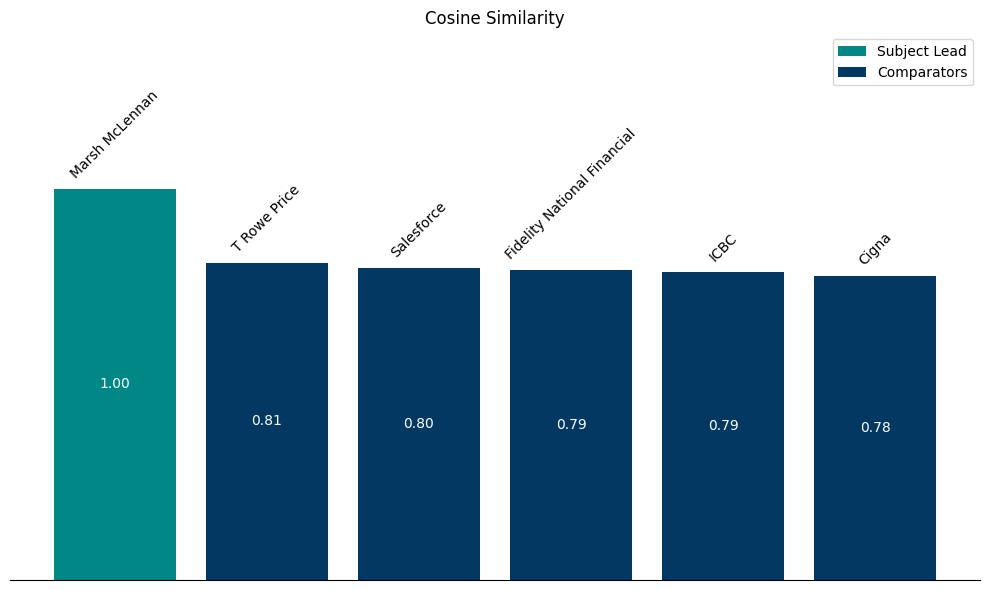

In [124]:
# Extract similarities and corresponding company names
similarities = cosine_similarity(np.array(subject_embedding).reshape(1, -1), np.vstack(df_matches['embedding'].values))[0]

# Get the subject lead's name using subject_snapshots
subject_name = subject_snapshots['company_name'].iloc[-1]

company_names = [subject_name] + df_matches['company_name'].tolist()  # Subject Lead first with name
all_similarities = [1] + list(similarities)  # Subject Lead similarity first
all_colors = ['#018785'] + ['#023861'] * len(similarities) # Subject Lead color first

# Create the bar plot
plt.figure(figsize=(10, 6))

# Plot similarities for subject lead and similar leads
bars = plt.bar(range(len(all_similarities)), all_similarities, color=all_colors) # Combine colors
plt.title("Cosine Similarity")

# Add company names as labels on top of the bars
for bar, name, sim in zip(bars, company_names, all_similarities):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{sim:.2f}', ha='center', va='center', color='white') # Display similarity inside the bar
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, name, ha='center', va='bottom', rotation=45)

# Remove x-axis ticks and labels
plt.xticks([])

# Remove y-axis ticks and labels
plt.yticks([])
plt.ylabel(None)  # Optional: Remove the y-axis label entirely

# Add legend to distinguish similar leads and subject lead
plt.legend(bars[:2], ['Subject Lead', 'Comparators']) # Use the first two bars for legend

# Hide top spine for x-axis ticks above 1.0 (if needed)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust y-axis limits for more space at the top
plt.ylim(0, 1.4)  # Or try 1.5 if needed

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# Agent Evaluator
Should summarize the state of the lead in the snapshot. Also, if it is a historical lead, the resulting 'why' of whether it converted, or lost (in negotiation or aged out etc) of the last snapshot should be explained. Have GPT take a look at the overall account and make up some plausible reason. This could be useful for GPT in providing explanations.

Initial snapshot summary model should refrain from making recommendations, and keep things matter of fact. The evaluation agent can make recommendations for seeking more information and things like **that**

In [66]:
# Comparator summaries and labels
comparator_summaries = list(zip(df_matches['snapshot_summary'], df_matches['converted']))

In [67]:
def write_scoring_prompt(subject_summary, comparator_summaries):
    comparator_text = "\n\n".join(
        [f"Comparator Lead {i+1}:\nSummary: {summary}\nConverted: {'Yes' if converted == 1 else 'No'}"
         for i, (summary, converted) in enumerate(comparator_summaries)]
    )

    prompt = f"""
You are a B2B sales expert evaluating the quality of a sales lead using both observed historical data and your general knowledge of sales strategy, buying cycles, and lead behavior patterns.
You are evaluating the quality of a sales lead based on how similar historical leads performed.

Subject Lead Summary:
{subject_summary}

Comparator leads are sorted by similarity to the subject lead (most similar first).
Each includes a summary and whether the lead converted or not.
Comparator Leads:
{comparator_text}

Evaluate the Subject Lead on the following dimensions, each scored from 1–100. Use both observed patterns in the comparator leads and broader sales knowledge.

Dimensions:
1. Company Fit
  - How well the lead aligns with the company’s ideal customer profile, including industry, size, scale, deal_value, cyber investment, and tech stack.
2. Engagement Quality
  - The level of activity and interest shown by the lead (downloads, meetings, decision-maker involvement)
  - The level of contact seniority involved.
  - Whether there is a current contract with a competitor solution and when the renewal date is
3. Pipeline Progress Potential
  - The current stage of this lead. Later stages require more attention.
  - The likelihood this lead will advance toward a sale based on similarity to converted leads and observed behaviors.

Ratings:
1. Company Fit:
2. Engagement Quality:
3. Pipeline Progress Potential:

Provide a short explanation for each rating.
Then, provide an overall **Lead Priority Score** from 0–100 that reflects how much attention this lead deserves.

Provide speculative recommendations or ideas to increase the likelihood of success for this lead. These can include engagement strategies, messaging adjustments, or other actions. Draw from both comparator patterns and general sales expertise.
""".strip()

    return prompt

In [68]:
prompt = write_scoring_prompt(subject_summary, comparator_summaries)
print(prompt)

You are a B2B sales expert evaluating the quality of a sales lead using both observed historical data and your general knowledge of sales strategy, buying cycles, and lead behavior patterns.
You are evaluating the quality of a sales lead based on how similar historical leads performed.

Subject Lead Summary:
Company Summary: Las Vegas Sands is a prominent player in the Gaming & Hospitality industry, renowned for its expertise in providing world-class entertainment experiences through its luxurious resorts and casinos. With a workforce of over 50,000 employees and annual revenues exceeding $13 billion, the company stands as an established leader in the market.

In terms of technology, Las Vegas Sands likely leverages a sophisticated tech stack to enhance customer engagement and operational efficiency. They probably have a robust data infrastructure, allowing them to collect and analyze high-value customer insights to tailor services. Embracing cloud platforms would enable the company to

In [69]:
def generate_score(prompt, temperature=0.7, max_tokens=600):

    # Use the new API method for generating completions
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=temperature,
        max_tokens=max_tokens
    )
    response = response.choices[0].message.content.strip()

    return response

priority_response = generate_score(prompt)

In [70]:
print(priority_response)

Ratings:
1. Company Fit: 85
Las Vegas Sands fits well with the ideal customer profile. It is a prominent player in its industry with a large workforce and high annual revenues. However, the low investment in cyber technology and lack of information about competitor solutions slightly lowers the score.

2. Engagement Quality: 35
Engagement has been minimal and inconsistent. The lead has shown little activity and interest in terms of downloads and website visits. The recent progression in contact seniority to the Director level is a positive sign, but without any information about a competitor contract, it's hard to predict their readiness to switch solutions.

3. Pipeline Progress Potential: 40
The lead has been in the Prospecting stage for 23 weeks with no progress, which indicates a low potential for pipeline progress based on the comparator leads. The leads that had a similar history and did not progress beyond the Prospecting stage did not convert. 

Lead Priority Score: 45
This sco

# Evaluation Model
The evaluation model could send the entire history of the historical comparator, as it could provide insight into how the lead reached conversion or lost.

# Predictive Model for Score

# Dashboard
1. Simple list of leads by score. List of leads by pipeline stage
2. Lead cliked shows explanatory breakdown and most similar k leads
3. Filter view by lead features
4. Can also use power BI

Even if no dashboard demo, can do slides


Is streamlit pretty easy? My vision is that it can intake a lead, it can be run through a function to determine most similar leads by cosine similarity, and then that all gets sent to GPT for evaluation.

The text model also goes into a pytorch model for a classification prediction.

The results can be output to the user.

It would also be great if I can show visualizations of historical and open data in plots and graphs. Bonus if they allow filtering and drilldown like an official dashboard.

How viable is all this in a day?